# Setup

In [1]:
# ==============================================================================
# ACTIVIDAD 1 — Limpieza de datos y reporte exploratorio de calidad
# Dataset: NYC Yellow Taxi Trip Records (enero 2017) + Taxi Zone Lookup
# ==============================================================================

import gc
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


def encabezado(titulo: str):
    """Imprime un separador visual consistente para cada sección del análisis."""
    print("=" * 80)
    print(titulo)
    print("=" * 80)


print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


# Carga de datos

In [2]:
encabezado("CARGA DE DATOS")

# Se usa pyarrow directamente (en vez de pd.read_parquet) para reducir el pico de
# memoria: to_pandas(self_destruct=True) libera cada bloque de Arrow apenas se
# copia a pandas, en vez de mantener ambas copias en memoria al mismo tiempo.
tabla = pq.read_table(r"C:\Users\juand\OneDrive\Escritorio\Especializacion\taxi-demand-project\data\raw\yellow_tripdata_2017-01.parquet")
df = tabla.to_pandas(split_blocks=True, self_destruct=True)
del tabla
gc.collect()

lookup = pd.read_csv(r"C:\Users\juand\OneDrive\Escritorio\Especializacion\taxi-demand-project\data\raw\taxi_zone_lookup (1).csv")

print(f"Viajes cargados    : {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"Zonas en lookup    : {lookup.shape[0]} registros")
print(f"Memoria del dataset: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
print(f"Rango de fechas    : {df['tpep_pickup_datetime'].min()} → {df['tpep_pickup_datetime'].max()}")

CARGA DE DATOS
Viajes cargados    : 9,710,820 filas | 19 columnas
Zonas en lookup    : 265 registros
Memoria del dataset: 1,796.5 MB
Rango de fechas    : 2017-01-01 00:00:00 → 2017-01-31 23:59:59


### Introducción al dataset y propósito del preprocesamiento
Este análisis se centra en el dataset público NYC Yellow Taxi Trip Records (enero 2017), publicado por la NYC Taxi & Limousine Commision, cada fila representa un registro de viaje individual de taxi amarillo con información de fechas, ubicaciones, distancia, tarifas y formas de pago. Con un total de 9,710,820 registros. Teniendo en cuenta que las ubicaciones están disponibles únicamente como códigos numérico, es necesario complementar con el archivo CSV de zone lookup que cumple la función de traducir cada código a su respectiva zona, distrito y tipo de servicio correspondiente, lo que habilita un análisis geográficamente interpretable. El propósito de este procesamiento es generar un diagnóstico complejo de la calidad de los datos, desde la cobertura de tipos de variables, hasta valores faltantes, duplicados y atípicos/inválidos, que permitan sustentar, con evidencia y no solo intuición, las decisiones de limpieza se apliquen antes de cualquier análisis o modelado posterior.

# Unión con zone lookup

In [3]:
encabezado("UNIÓN CON TAXI ZONE LOOKUP")

# El lookup se renombra antes de mergear (con prefijo PU/DO) para que la llave
# quede alineada por nombre y no se generen columnas duplicadas con sufijos _x/_y.
lookup_pu = lookup.rename(columns={
    'LocationID': 'PULocationID', 'Borough': 'PUBorough',
    'Zone': 'PUZone', 'service_zone': 'PUservice_zone'
})
lookup_do = lookup.rename(columns={
    'LocationID': 'DOLocationID', 'Borough': 'DOBorough',
    'Zone': 'DOZone', 'service_zone': 'DOservice_zone'
})

n_filas_antes = df.shape[0]
df = pd.merge(df, lookup_pu, on='PULocationID', how='left')
df = pd.merge(df, lookup_do, on='DOLocationID', how='left')
gc.collect()

print(f"Filas antes del merge  : {n_filas_antes:,}")
print(f"Filas después del merge: {df.shape[0]:,}")
print(f"¿Se mantuvo el número de filas? {'Sí' if n_filas_antes == df.shape[0] else 'No — revisar duplicados en lookup'}")
print(f"Memoria tras unión: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
df.head(3)

UNIÓN CON TAXI ZONE LOOKUP
Filas antes del merge  : 9,710,820
Filas después del merge: 9,710,820
¿Se mantuvo el número de filas? Sí
Memoria tras unión: 2,957.8 MB


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,PUBorough,PUZone,PUservice_zone,DOBorough,DOZone,DOservice_zone
0,1,2017-01-01 00:32:05,2017-01-01 00:37:48,1,1.2,1,N,140,236,2,6.5,0.5,0.5,0.0,0.0,0.3,7.8,None,None,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone
1,1,2017-01-01 00:43:25,2017-01-01 00:47:42,2,0.7,1,N,237,140,2,5.0,0.5,0.5,0.0,0.0,0.3,6.3,None,None,Manhattan,Upper East Side South,Yellow Zone,Manhattan,Lenox Hill East,Yellow Zone
2,1,2017-01-01 00:49:10,2017-01-01 00:53:53,2,0.8,1,N,140,237,2,5.5,0.5,0.5,0.0,0.0,0.3,6.8,None,None,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone


### Unión con Taxi Zone Lookup

La unión se realizó a partir de dos left join independientes, uno para PULocationID y otro para DOLocationID, con la finalidad de conservar el 100% de las filas originales. Esta unión permitió evidenciar de forma indirecta un problema de calidad en el propio archivo de referencia, ya que los códigos 264 y 265 traen campos vacíos en Zone, Borough y service_zone, lo que se documenta en detalle en la sección de valores faltantes.

# Clasificación de variables

In [4]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge             object
airport_fee                      object
PUBorough                           str
PUZone                              str
PUservice_zone                      str
DOBorough                           str
DOZone                              str
DOservice_zone                      str


In [5]:
encabezado("CLASIFICACIÓN DE VARIABLES")

# Clasificación basada en conocimiento del dominio: la cardinalidad por sí sola
# no distingue entre una variable numérica (donde promediar/sumar tiene sentido)
# y un código categórico representado con números (PULocationID, VendorID, etc.)
variables_temporales = ['tpep_pickup_datetime', 'tpep_dropoff_datetime']
variables_categoricas = ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
                          'payment_type', 'PUBorough', 'PUZone', 'PUservice_zone',
                          'DOBorough', 'DOZone', 'DOservice_zone']
variables_discretas = ['passenger_count']
variables_continuas = ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
                        'tolls_amount', 'improvement_surcharge', 'total_amount']
variables_no_disponibles = ['congestion_surcharge', 'airport_fee']

todas_clasificadas = (variables_temporales + variables_discretas +
                       variables_continuas + variables_categoricas +
                       variables_no_disponibles)
faltantes_por_clasificar = set(df.columns) - set(todas_clasificadas)

print(f"Temporales ({len(variables_temporales)})")
print(f"Categóricas ({len(variables_categoricas)})")
print(f"Discretas ({len(variables_discretas)})")
print(f"Continuas ({len(variables_continuas)})")
print(f"No disponibles en este archivo ({len(variables_no_disponibles)}): {variables_no_disponibles}")
print(f"\n¿Quedó alguna columna sin clasificar? {faltantes_por_clasificar if faltantes_por_clasificar else 'No'}")

CLASIFICACIÓN DE VARIABLES
Temporales (2)
Categóricas (12)
Discretas (1)
Continuas (8)
No disponibles en este archivo (2): ['congestion_surcharge', 'airport_fee']

¿Quedó alguna columna sin clasificar? No


### Clasificación de variables

Se optó por una clasificación basada en en conocimiento del dominio en vez de puramente automática por dtype/cardinalidad, esto debido a que este segundo criterio clasifica incorrectamente columnas como PULocationID que es un código y no una cantidad a pesar de ser numérico. El dataset quedó clasificado en 2 variables temporales, 12 categóricas, 1 discreta, 8 continuas y 2 no disponibles en este archivo, ya que no cuentan con registros en el esquema de enero de 2017.

# Faltantes resumen global

In [6]:
encabezado("VALORES FALTANTES: RESUMEN GLOBAL")

faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
pct_faltantes = (faltantes / len(df) * 100).round(2)

resumen_faltantes = pd.DataFrame({'n_faltantes': faltantes, 'pct_faltantes': pct_faltantes})
print(resumen_faltantes)

VALORES FALTANTES: RESUMEN GLOBAL
                      n_faltantes  pct_faltantes
congestion_surcharge      9710820         100.00
airport_fee               9710820         100.00
DOservice_zone             173506           1.79
PUservice_zone             170016           1.75
PUZone                     165493           1.70
DOZone                     152284           1.57
DOBorough                   21222           0.22
PUBorough                    4523           0.05


# Faltantes IDs responsables

In [7]:
encabezado("VALORES FALTANTES: IDs RESPONSABLES")

# Se investiga por separado en pickup y dropoff, ya que son merges independientes
ids_pu_zone_nulos = df.loc[df['PUZone'].isnull(), 'PULocationID'].unique()
ids_do_zone_nulos = df.loc[df['DOZone'].isnull(), 'DOLocationID'].unique()
ids_pu_borough_nulos = df.loc[df['PUBorough'].isnull(), 'PULocationID'].unique()
ids_do_borough_nulos = df.loc[df['DOBorough'].isnull(), 'DOLocationID'].unique()
ids_pu_service_nulos = df.loc[df['PUservice_zone'].isnull(), 'PULocationID'].unique()
ids_do_service_nulos = df.loc[df['DOservice_zone'].isnull(), 'DOLocationID'].unique()

print(f"PULocationID responsables de nulos en PUZone: {ids_pu_zone_nulos}")
print(f"DOLocationID responsables de nulos en DOZone: {ids_do_zone_nulos}")
print(f"\nPULocationID responsables de nulos en PUBorough: {ids_pu_borough_nulos}")
print(f"DOLocationID responsables de nulos en DOBorough: {ids_do_borough_nulos}")
print(f"\nPULocationID responsables de nulos en PUservice_zone: {ids_pu_service_nulos}")
print(f"DOLocationID responsables de nulos en DOservice_zone: {ids_do_service_nulos}")

VALORES FALTANTES: IDs RESPONSABLES
PULocationID responsables de nulos en PUZone: [264]
DOLocationID responsables de nulos en DOZone: [264]

PULocationID responsables de nulos en PUBorough: [265]
DOLocationID responsables de nulos en DOBorough: [265]

PULocationID responsables de nulos en PUservice_zone: [265 264]
DOLocationID responsables de nulos en DOservice_zone: [264 265]


# Faltantes causa raíz en el lookup

In [8]:
encabezado("VALORES FALTANTES: CAUSA RAÍZ EN EL LOOKUP")

print("Registro(s) del lookup que originan los nulos:")
lookup[lookup['LocationID'].isin([264, 265])]

VALORES FALTANTES: CAUSA RAÍZ EN EL LOOKUP
Registro(s) del lookup que originan los nulos:


,LocationID,Borough,Zone,service_zone
263,264,Unknown,NaN,NaN
264,265,NaN,Outside of NYC,NaN


### Valores faltantes

El set de datos presenta dos tipos de faltantes con causas completamente distintas congestion_surcharge y airport_fee están en el 100% de los 9,710,820 registros porque estos campos probablemente no formaban parte del esquema de datos de enero de 2017, esto es una limitación de disponibilidad histórica más no un error de captura. Por otro lado, entre el 0.05% y el 1.79% de los registros carecen de Zone/Borough/service_zone, concentrados exclusivamente en los LocationID 264 ("Unknown") y 265 ("Outside of NYC"), cuyos propios campos vienen ovación en el archivo de referencia de Taxi Zone Lookup. Para esto se recomienda tratar estas dos causas por separado, por un lado, eliminar las columnas completamente vacías y para los nulos de zona, sustituir por una categoría explícita ("Unknown") en vez de eliminar el registro, ya que el resto de la información del viaje es válida. 

# Duplicados exactos

In [9]:
encabezado("DUPLICADOS EXACTOS")

n_dup_exactos = df.duplicated().sum()
pct_dup_exactos = n_dup_exactos / len(df) * 100

print(f"Filas completamente duplicadas: {n_dup_exactos:,} ({pct_dup_exactos:.3f}%)")

DUPLICADOS EXACTOS
Filas completamente duplicadas: 0 (0.000%)


# Duplicados lógicos

In [10]:
encabezado("DUPLICADOS LÓGICOS")

# Un viaje queda identificado por: mismo proveedor, mismo horario de recogida y
# entrega, y mismo par origen-destino. Si estos 5 campos coinciden entre dos
# filas, es probable que sea el mismo viaje registrado dos veces, aunque
# difieran en columnas secundarias.
columnas_clave_viaje = ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
                         'PULocationID', 'DOLocationID']

n_dup_logicos = df.duplicated(subset=columnas_clave_viaje).sum()
pct_dup_logicos = n_dup_logicos / len(df) * 100

print(f"Duplicados lógicos (misma clave de viaje): {n_dup_logicos:,} ({pct_dup_logicos:.3f}%)")

DUPLICADOS LÓGICOS
Duplicados lógicos (misma clave de viaje): 4,544 (0.047%)


### Duplicados 

Se identificaron 0 duplicados exactos (fila idéntica en todas las columnas), pero se encontraron 4,544 duplicados lógicos, los cuales contaban con el mismo proveedor, mismos timestamps de recogida y entrega, y mismo par origen-destino. Al inspeccionar los pares, los valores secundarios, coinciden entre sí, lo cual descarta que sean viajes genuinamente distintos coincidiendo por azar y más bien apunta a un error de captura del sistema por lo que es recomendado eliminarlos antes de cualquier análisis o modelado, conservando solo un registro por grupo duplicado.

# Preparación: Duración del viaje

In [11]:
encabezado("PREPARACIÓN: DURACIÓN DEL VIAJE")

# Variable derivada, útil como control de calidad: un viaje con duración <= 0
# (dropoff antes o igual que pickup) es evidencia directa de error de registro,
# no un valor "raro" que dependa de un umbral estadístico.
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

print(f"Duración promedio: {df['trip_duration_min'].mean():.2f} min")
print(f"Duración mínima  : {df['trip_duration_min'].min():.2f} min")
print(f"Duración máxima  : {df['trip_duration_min'].max():.2f} min")

PREPARACIÓN: DURACIÓN DEL VIAJE
Duración promedio: 14.84 min
Duración mínima  : -60400.25 min
Duración máxima  : 1439.93 min


# Outliers por rango intercuartílico (IQR)

In [12]:
encabezado("OUTLIERS POR RANGO INTERCUARTÍLICO (IQR)")

def resumen_outliers_iqr(df, col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    return {
        'variable': col, 'Q1': round(q1, 2), 'Q3': round(q3, 2),
        'limite_inferior': round(lim_inf, 2), 'limite_superior': round(lim_sup, 2),
        'n_outliers': n_outliers, 'pct_outliers': round(n_outliers / len(df) * 100, 3)
    }

variables_revisar = ['trip_distance', 'fare_amount', 'total_amount', 'trip_duration_min', 'passenger_count']
resumen = pd.DataFrame([resumen_outliers_iqr(df, col) for col in variables_revisar])
print(resumen.to_string(index=False))

OUTLIERS POR RANGO INTERCUARTÍLICO (IQR)
         variable   Q1    Q3  limite_inferior  limite_superior  n_outliers  pct_outliers
    trip_distance 0.95  2.90            -1.97             5.82     1055414        10.868
      fare_amount 6.50 13.50            -4.00            24.00      896631         9.233
     total_amount 8.30 16.73            -4.34            29.38      887443         9.139
trip_duration_min 6.23 16.68            -9.44            32.36      500118         5.150
  passenger_count 1.00  2.00            -0.50             3.50      955316         9.838


# Valores negativos en variables monetarias

In [13]:
encabezado("VALORES NEGATIVOS EN VARIABLES MONETARIAS")

variables_no_negativas = ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
                           'tolls_amount', 'improvement_surcharge', 'total_amount']

resumen_negativos = []
for col in variables_no_negativas:
    n_negativos = (df[col] < 0).sum()
    resumen_negativos.append({
        'variable': col, 'n_negativos': n_negativos,
        'pct_negativos': round(n_negativos / len(df) * 100, 4)
    })

resumen_negativos = pd.DataFrame(resumen_negativos)
print(resumen_negativos.to_string(index=False))

VALORES NEGATIVOS EN VARIABLES MONETARIAS
             variable  n_negativos  pct_negativos
        trip_distance            0         0.0000
          fare_amount         4542         0.0468
                extra         2177         0.0224
              mta_tax         4407         0.0454
           tip_amount           81         0.0008
         tolls_amount           17         0.0002
improvement_surcharge         4541         0.0468
         total_amount         4544         0.0468


# Casos puntuales sospechosos

In [14]:
encabezado("CASOS PUNTUALES SOSPECHOSOS")

print(f"Distancia == 0 con tarifa > 0  : {((df['trip_distance'] == 0) & (df['fare_amount'] > 0)).sum():,}")
print(f"Tarifa == 0 con distancia > 0  : {((df['fare_amount'] == 0) & (df['trip_distance'] > 0)).sum():,}")
print(f"RatecodeID fuera de rango (1-6): {(~df['RatecodeID'].isin(range(1, 7))).sum():,}")
print(f"Duración <= 0                  : {(df['trip_duration_min'] <= 0).sum():,}")

CASOS PUNTUALES SOSPECHOSOS
Distancia == 0 con tarifa > 0  : 57,169
Tarifa == 0 con distancia > 0  : 1,521
RatecodeID fuera de rango (1-6): 178
Duración <= 0                  : 9,343


# Montos negativos: ¿Mismas Filas?

In [15]:
encabezado("MONTOS NEGATIVOS: VERIFICACIÓN DE COINCIDENCIA ENTRE COLUMNAS")

# Se verifica si los conteos similares de negativos en fare_amount, mta_tax,
# improvement_surcharge y total_amount corresponden a las mismas filas
# (compatible con viajes cancelados/reembolsados) o a filas distintas.
mascara_negativos = (df['fare_amount'] < 0) | (df['mta_tax'] < 0) | \
                     (df['improvement_surcharge'] < 0) | (df['total_amount'] < 0)

filas_negativas = df[mascara_negativos]
print(f"Filas con al menos un monto negativo: {len(filas_negativas):,}")
print(f"Filas con TODOS los montos negativos a la vez: "
      f"{((filas_negativas['fare_amount'] < 0) & (filas_negativas['mta_tax'] < 0) & (filas_negativas['improvement_surcharge'] < 0) & (filas_negativas['total_amount'] < 0)).sum():,}")

filas_negativas[['fare_amount', 'mta_tax', 'tip_amount', 'improvement_surcharge', 'total_amount', 'payment_type']].head(10)

MONTOS NEGATIVOS: VERIFICACIÓN DE COINCIDENCIA ENTRE COLUMNAS
Filas con al menos un monto negativo: 4,544
Filas con TODOS los montos negativos a la vez: 4,403


,fare_amount,mta_tax,tip_amount,improvement_surcharge,total_amount,payment_type
767,-4.50,-0.5,0.0,-0.3,-5.80,4
999,-4.50,-0.5,0.0,-0.3,-5.80,4
4347,-4.00,-0.5,0.0,-0.3,-5.30,3
4721,-52.25,-0.5,0.0,-0.3,-53.05,4
7270,-5.50,-0.5,0.0,-0.3,-6.80,4
9185,-4.50,-0.5,0.0,-0.3,-5.80,3
10483,-3.50,-0.5,0.0,-0.3,-4.80,4
15131,-3.00,-0.5,0.0,-0.3,-4.30,3
15198,-4.50,-0.5,0.0,-0.3,-5.80,3
17493,-4.00,-0.5,0.0,-0.3,-5.30,3


# Duración negativa: Distribución detallada

In [16]:
encabezado("DURACIÓN NEGATIVA: DISTRIBUCIÓN DETALLADA")

df.loc[df['trip_duration_min'] < 0, 'trip_duration_min'].describe()

DURACIÓN NEGATIVA: DISTRIBUCIÓN DETALLADA


count        4.000000
mean    -17844.766667
std      28454.598307
min     -60400.250000
25%     -20089.025000
50%      -4749.700000
75%      -2505.441667
max      -1479.416667
Name: trip_duration_min, dtype: float64

# Duración igual a cero

In [17]:
encabezado("DURACIÓN IGUAL A CERO (pickup == dropoff exacto)")

viajes_duracion_cero = df[df['trip_duration_min'] == 0]
print(f"Viajes con duración == 0: {len(viajes_duracion_cero):,}")

viajes_duracion_cero[['trip_distance', 'fare_amount', 'total_amount']].describe()

DURACIÓN IGUAL A CERO (pickup == dropoff exacto)
Viajes con duración == 0: 9,339


,trip_distance,fare_amount,total_amount
count,9339.000000,9339.00000,9339.000000
mean,0.161202,79.79007,81.619295
std,1.727170,6476.61678,6476.615379
min,0.000000,-52.00000,-62.840000
25%,0.000000,2.50000,3.800000
50%,0.000000,6.50000,7.800000
75%,0.000000,13.50000,14.800000
max,71.980000,625900.80000,625901.600000


# Casos extremos: Mayores tarifas con duración cero

In [18]:
encabezado("CASOS EXTREMOS: MAYORES TARIFAS CON DURACIÓN CERO")

viajes_duracion_cero.nlargest(5, 'fare_amount')[['tpep_pickup_datetime', 'tpep_dropoff_datetime',
                                                    'trip_distance', 'fare_amount', 'total_amount', 'payment_type']]

CASOS EXTREMOS: MAYORES TARIFAS CON DURACIÓN CERO


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,payment_type
5561952,2017-01-19 09:29:44,2017-01-19 09:29:44,0.0,625900.80,625901.60,2
4592262,2017-01-16 01:02:23,2017-01-16 01:02:23,0.0,350.30,350.30,1
6639820,2017-01-22 13:56:47,2017-01-22 13:56:47,0.0,291.50,301.80,2
8248901,2017-01-27 14:20:07,2017-01-27 14:20:07,0.0,270.84,270.84,1
2889369,2017-01-10 20:51:09,2017-01-10 20:51:09,0.0,255.00,255.30,2


### Outliers y valores inválidos

El análisis por rango intercuartílico (IQR) muestra entre 5% y 11% de “outliers” en las variables monetarias, de distancia y de duración, siendo la mayoría explicados por la naturaleza sesgada de los datos de taxis con viajes largos y caros completamente legítimos, como trayectos al aeropuerto y no representan ningún tipo de error. Los hallazgos con evidencia real de invalidez son: 4 registros con duración negativa; 9,339 registros con duración exactamente igual a cero, gran parte tarifas mínimas por fallo de cierre del medidor, incluyendo un caso extremo de $625,900.80 por probable error de digitación; 57,169 registros con distancia igual a cero pero tarifa mayor a cero (limitación conocida, no hay evidencia suficiente para poder determinar si es un error o viaje corto sin registro de GPS); y 4,403 registros con montos negativos simultáneos en tarifa, impuesto y total, que probablemente sean consistentes con reembolsos o cancelaciones del sistema, más no con viajes completados. Por lo mencionado previamente, es recomendable excluir del análisis de demanda, los registros con duración ≤ 0 y los montos negativos simultáneos, y documentar como limitación conocida el caso de la distancia cero con tarifas positivas. 

# Boxplots de variables numéricas

BOXPLOTS: DISTRIBUCIÓN Y OUTLIERS (ESCALA SYMLOG)


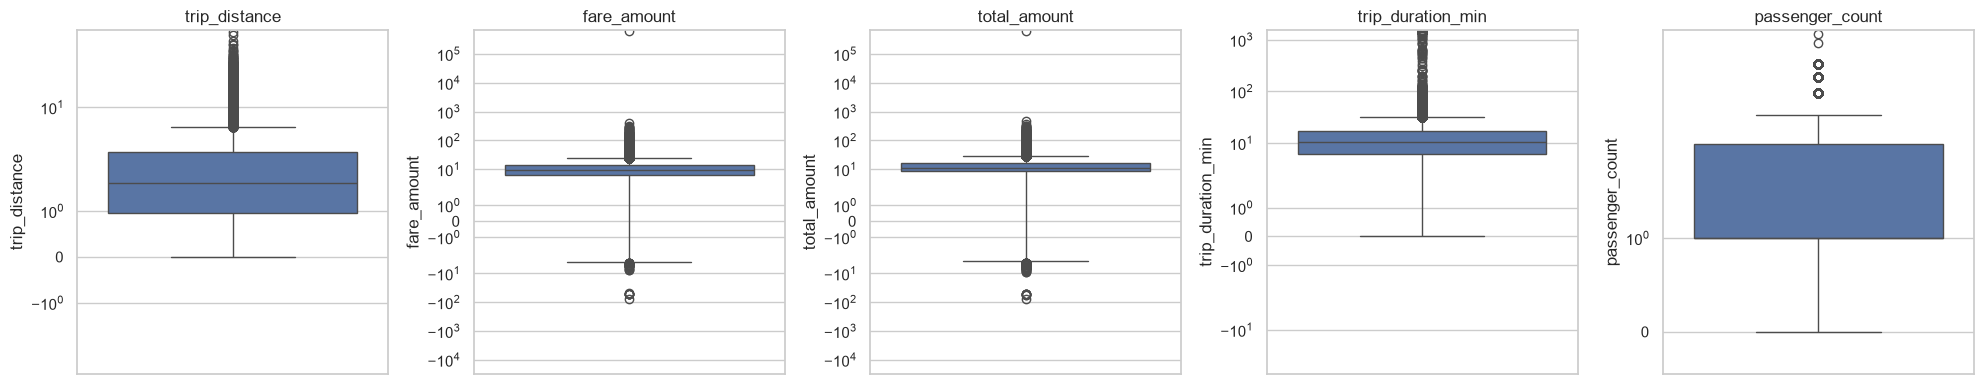

In [19]:
encabezado("BOXPLOTS: DISTRIBUCIÓN Y OUTLIERS (ESCALA SYMLOG)")

# Se grafica sobre una muestra aleatoria, no sobre las 9.7M de filas completas:
# dibujar cada punto atípico individual con ese volumen de datos es computacionalmente
# costoso y no aporta más información que el conteo de outliers por IQR ya calculado.

muestra = df[variables_revisar].sample(n=200_000, random_state=42)

fig, axes = plt.subplots(1, len(variables_revisar), figsize=(20, 4))
for ax, col in zip(axes, variables_revisar):
    sns.boxplot(y=muestra[col], ax=ax)
    ax.set_yscale('symlog')
    ax.set_title(col)
plt.tight_layout()
plt.show()

BOXPLOTS: ZOOM A LA DISTRIBUCIÓN TÍPICA (PERCENTIL 99)


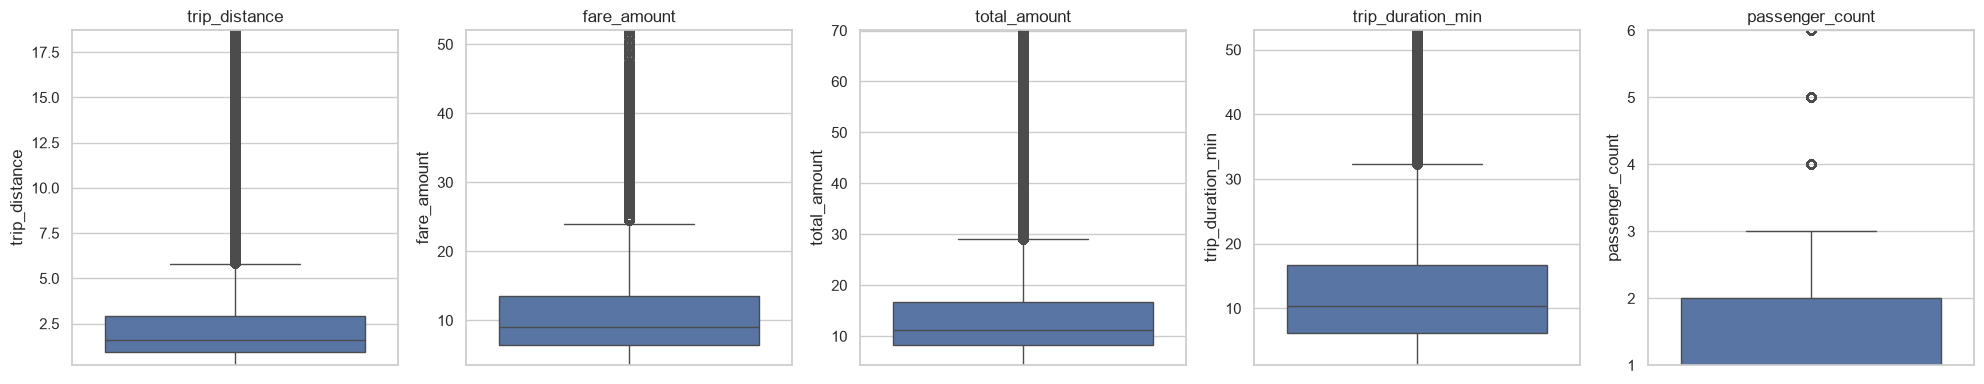

In [20]:
encabezado("BOXPLOTS: ZOOM A LA DISTRIBUCIÓN TÍPICA (PERCENTIL 99)")

# Complementa el gráfico symlog: aquí se recorta solo el rango visual del eje,
# no los datos — los valores extremos ya quedaron documentados en las tablas
# de outliers e IQR previas.
fig, axes = plt.subplots(1, len(variables_revisar), figsize=(20, 4))
for ax, col in zip(axes, variables_revisar):
    p99 = muestra[col].quantile(0.99)
    p1 = muestra[col].quantile(0.01)
    sns.boxplot(y=muestra[col], ax=ax)
    ax.set_ylim(p1, p99)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Mapa de valores faltantes (Columnas con bajo % de faltantes)

MAPA VISUAL DE FALTANTES (EXCLUYENDO COLUMNAS 100% VACÍAS)


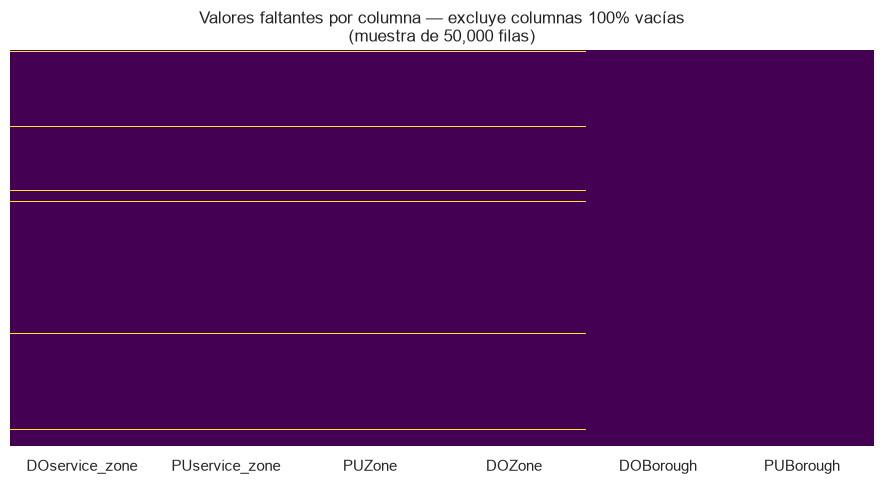

In [21]:
encabezado("MAPA VISUAL DE FALTANTES (EXCLUYENDO COLUMNAS 100% VACÍAS)")

# Se excluyen congestion_surcharge y airport_fee: al estar 100% vacias, su escala
# domina el heatmap y no permite distinguir el patron en el resto de columnas.
cols_bajo_pct = resumen_faltantes[resumen_faltantes['pct_faltantes']<100].index.tolist()
muestra_faltantes = df[cols_bajo_pct].sample(50_000, random_state=42)

fig, ax = plt.subplots(figsize = (9, 5))
sns.heatmap(muestra_faltantes.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Valores faltantes por columna — excluye columnas 100% vacías\n(muestra de 50,000 filas)')
plt.tight_layout()
plt.show()

# Barras (todas las columnas, incluye las de 100%)

VALORES FALTANTES: MAGNITUD POR COLUMNA


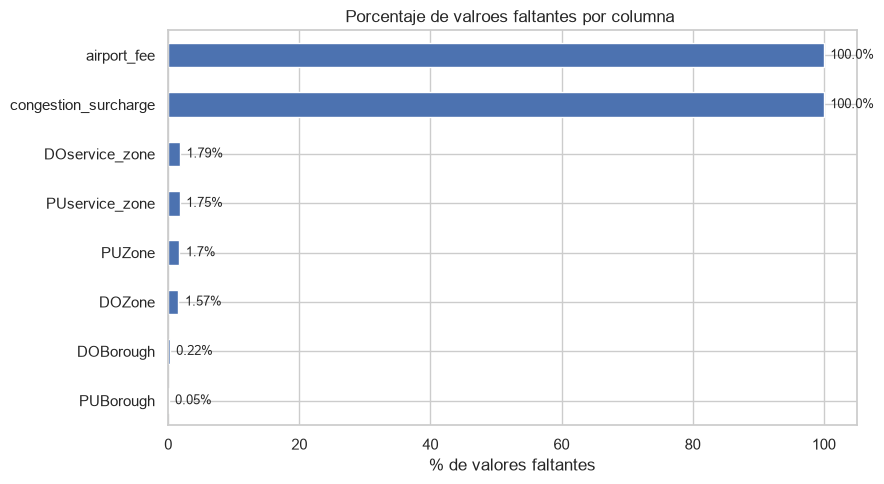

In [22]:
encabezado("VALORES FALTANTES: MAGNITUD POR COLUMNA")

fig, ax = plt.subplots(figsize=(9, 5))
resumen_faltantes.sort_values('pct_faltantes')['pct_faltantes'].plot(
    kind='barh', ax=ax, color='#4C72B0'
)

ax.set_xlabel('% de valores faltantes')
ax.set_title('Porcentaje de valroes faltantes por columna ')

for i, v in enumerate (resumen_faltantes.sort_values('pct_faltantes')['pct_faltantes']):
    ax.text(v + 1, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Resumen estadístico general

In [23]:
encabezado("RESUMEN ESTADÍSTICO — VARIABLES NUMÉRICAS")

df[variables_continuas + variables_discretas].describe().T

RESUMEN ESTADÍSTICO — VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
trip_distance,9710820.0,2.813879,3.611637,0.0,0.95,1.6,2.90,264.71
fare_amount,9710820.0,12.374141,265.222000,-350.0,6.50,9.0,13.50,625900.80
extra,9710820.0,0.323484,0.442552,-55.2,0.00,0.0,0.50,55.54
mta_tax,9710820.0,0.497523,0.048813,-0.5,0.50,0.5,0.50,56.50
tip_amount,9710820.0,1.751259,2.571219,-41.0,0.00,1.3,2.26,999.99
tolls_amount,9710820.0,0.276409,1.638808,-15.0,0.00,0.0,0.00,911.08
improvement_surcharge,9710820.0,0.299680,0.013421,-0.3,0.30,0.3,0.30,0.30
total_amount,9710820.0,15.526621,265.338411,-350.3,8.30,11.3,16.73,625901.60
passenger_count,9710820.0,1.629222,1.272268,0.0,1.00,1.0,2.00,9.00


# Resumen ejecutivo de calidad de datos

In [24]:
encabezado("RESUMEN EJECUTIVO DE CALIDAD DE DATOS")

resumen_ejecutivo = pd.DataFrame([
    {'hallazgo': 'Total de registros', 'valor': f"{len(df):,}"},
    {'hallazgo': 'Columnas 100% vacías', 'valor': 'congestion_surcharge, airport_fee (no existían en el esquema de enero 2017)'},
    {'hallazgo': 'Faltantes en zona (Zone/Borough/service_zone)', 'valor': f"Concentrados en LocationID 264 y 265 (~{faltantes['PUZone']+faltantes['DOZone']:,} registros afectados en Zone)"},
    {'hallazgo': 'Duplicados exactos', 'valor': f"{n_dup_exactos:,} ({pct_dup_exactos:.3f}%)"},
    {'hallazgo': 'Duplicados lógicos', 'valor': f"{n_dup_logicos:,} ({pct_dup_logicos:.3f}%)"},
    {'hallazgo': 'Duración de viaje negativa', 'valor': f"{(df['trip_duration_min'] < 0).sum():,} (errores de timestamp extremos)"},
    {'hallazgo': 'Duración de viaje igual a cero', 'valor': f"{len(viajes_duracion_cero):,}"},
    {'hallazgo': 'Montos negativos coincidentes', 'valor': f"{((df['fare_amount'] < 0) & (df['mta_tax'] < 0) & (df['improvement_surcharge'] < 0) & (df['total_amount'] < 0)).sum():,} (compatible con reembolsos/cancelaciones)"},
    {'hallazgo': 'Distancia == 0 con tarifa > 0', 'valor': f"{((df['trip_distance'] == 0) & (df['fare_amount'] > 0)).sum():,}"},
])

pd.set_option('display.max_colwidth', None)
resumen_ejecutivo

RESUMEN EJECUTIVO DE CALIDAD DE DATOS


,hallazgo,valor
0,Total de registros,"9,710,820"
1,Columnas 100% vacías,"congestion_surcharge, airport_fee (no existían en el esquema de enero 2017)"
2,Faltantes en zona (Zone/Borough/service_zone),"Concentrados en LocationID 264 y 265 (~317,777 registros afectados en Zone)"
3,Duplicados exactos,0 (0.000%)
4,Duplicados lógicos,"4,544 (0.047%)"
5,Duración de viaje negativa,4 (errores de timestamp extremos)
6,Duración de viaje igual a cero,"9,339"
7,Montos negativos coincidentes,"4,403 (compatible con reembolsos/cancelaciones)"
8,Distancia == 0 con tarifa > 0,"57,169"


# Limpieza

In [25]:
encabezado("LIMPIEZA DE DATOS")

def limpiar_viajes_taxi(df): 
    """
    Aplica reglas de limpieza determinísticas, justificadas y documentadas
    en el reporte exploratorio de esta actividad.
    """
    df = df.copy()
    n_inicial = len(df)

    # 1. Columnas sin información utilizable (100% vacías en este archivo)
    df = df.drop(columns=['congestion_surcharge', 'airport_fee'])

    # 2. Zona/borough/service_zone nulos: se reemplaza por categoria explícita
    #    en vez de eliminar el viaje, ya que el resto del registro es valido
    for col in ['PUZone', 'PUBorough', 'PUservice_zone', 'DOZone', 'DOBorough', 'DOservice_zone']:
        df[col] = df[col].fillna('unknown')

    # 3. Duplicados lógicos: mismo viaje registrado más de una vez
    columnas_clave_viaje = ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
                             'PULocationID', 'DOLocationID']
    df = df.drop_duplicates(subset=columnas_clave_viaje, keep='first')

    # 4. Viajes con duración <= 0: no representan un trayecto válido
    df = df[df['trip_duration_min']>0]

    # 5. Montos negativos simultáneos: reembolsos/cancelaciones, no viajes completados
    df = df[~((df['fare_amount']<0) & (df['total_amount']<0))]

    n_final = len(df)
    print(f"Filas antes de limpieza: {n_inicial}")
    print(f"Filas después de limpieza: {n_final}")
    print(f"Filas eliminadas: {n_inicial - n_final:,} ({(n_inicial - n_final)/n_inicial*100:.3}%)")

    return df

df_limpio = limpiar_viajes_taxi(df)

LIMPIEZA DE DATOS
Filas antes de limpieza: 9710820
Filas después de limpieza: 9692403
Filas eliminadas: 18,417 (0.19%)


### Conclusión general

El set de datos de NTC Yellow Taxi Trip Records (enero 2017) presentó una calidad de datos generalmente sólida, en la cual no se encontró duplicados exactos, sin errores masivos de tipo de dato y con la gran mayoría de sus valores “atípicos” explicables por naturaleza propia del tipo de negocio más que por errores de captura. Lo problemas de calidad que se encontraron fueron puntuales pero bien delimitados, entre estos dos columnas inexistentes en el esquema de la fecha, faltantes de zona concentrados en dos códigos específicos del archivo de referencia (264 y 265), 4,544 duplicados lógicos y un conjunto de registros que pueden ser compatibles con errores del sistema o reembolsos. Posterior a aplicar las reglas de limpieza que fueron justificadas en cada una de las secciones, se eliminó un 0.19 % de los registros, por lo que se conservó la mayor parte de la información original. Lo mencionado previamente nos permitió obtener como resultado df_limpio el cual queda en condiciones adecuadas para el análisis exploratorio y de modelado que se puedan llegar a desarrollar en un futuro. 

In [26]:
encabezado("EXPORTACIÓN DEL DATASET LIMPIO")

# Se guarda en formato parquet para preservar los dtypes optimizados
# y evitar tener que re-declarar tipos al recargar en el notebook siguiente
df_limpio.to_parquet('../../data/processed/trips_limpio_2017-01.parquet', index=False)
print(f"Dataset limpio exportado: {df_limpio.shape[0]:,} filas | {df_limpio.shape[1]} columnas")

EXPORTACIÓN DEL DATASET LIMPIO
Dataset limpio exportado: 9,692,403 filas | 24 columnas
